正在执行两表合并...

开始生成图表...


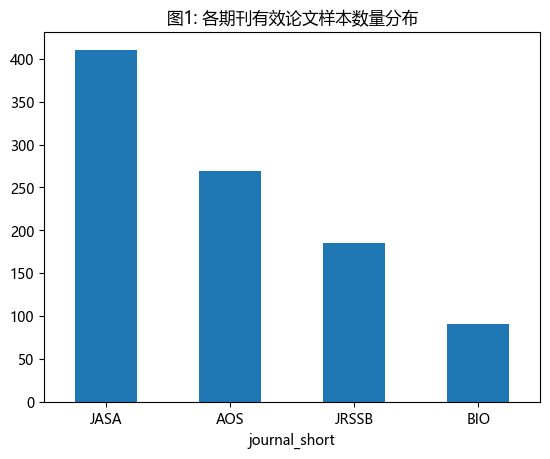

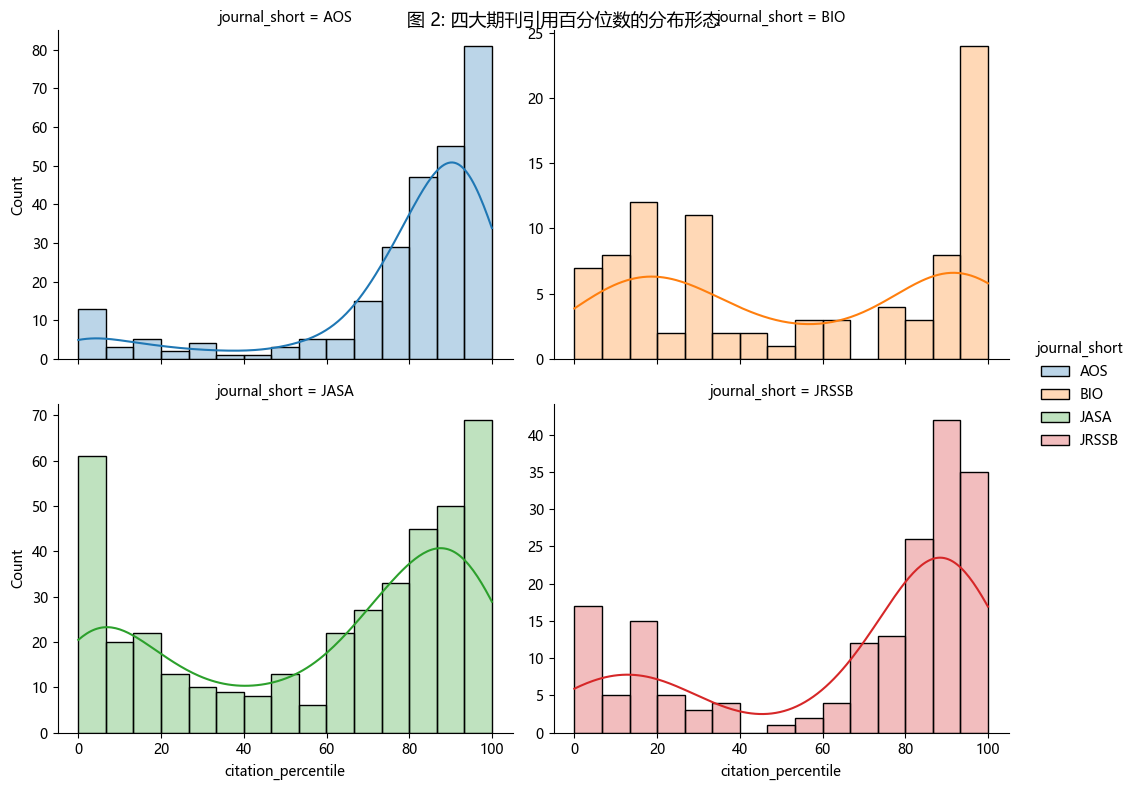

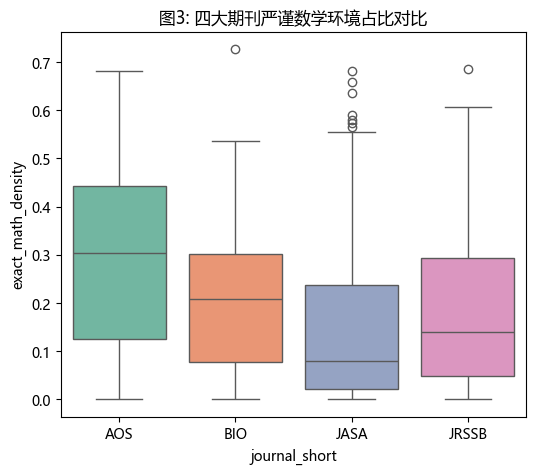

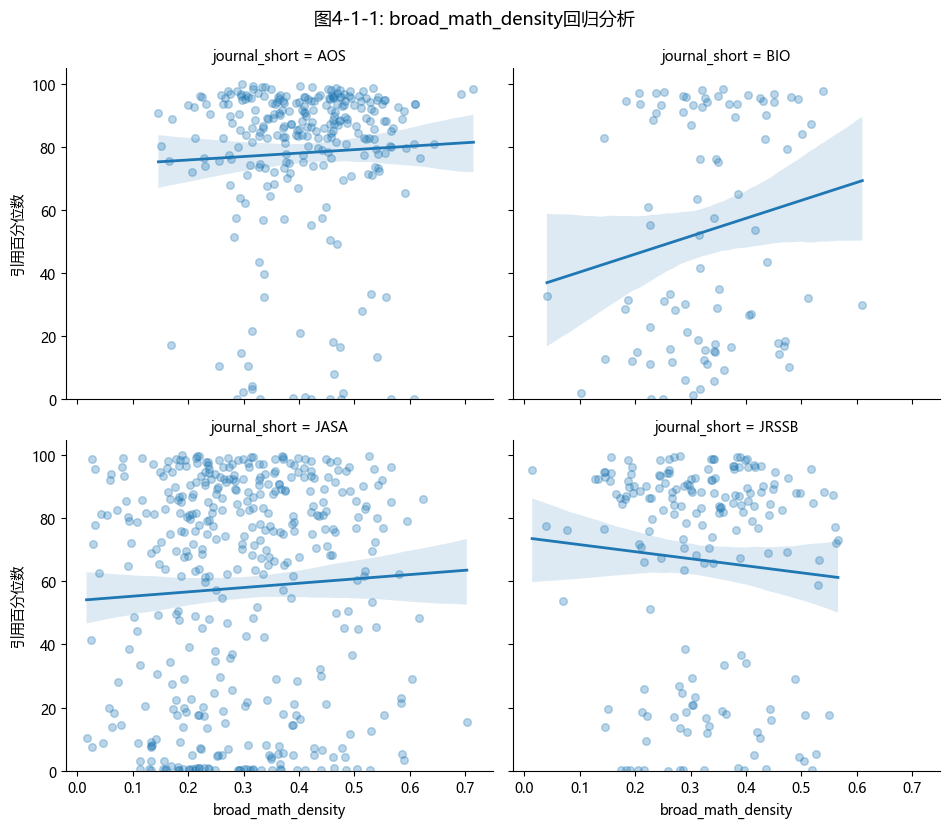

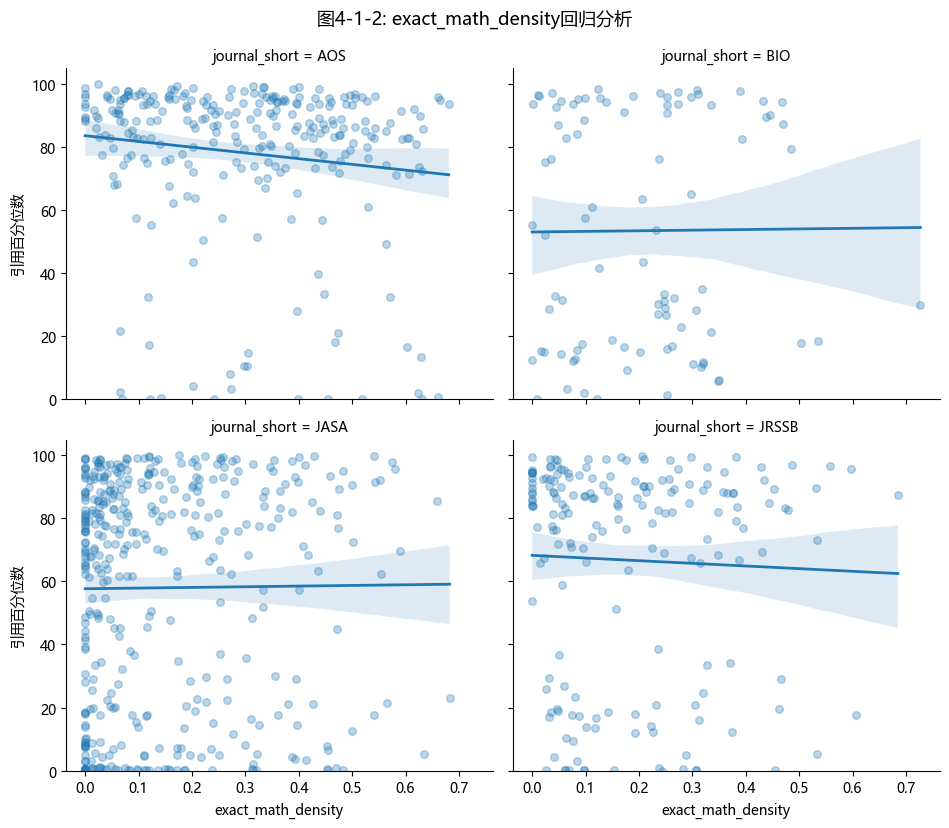

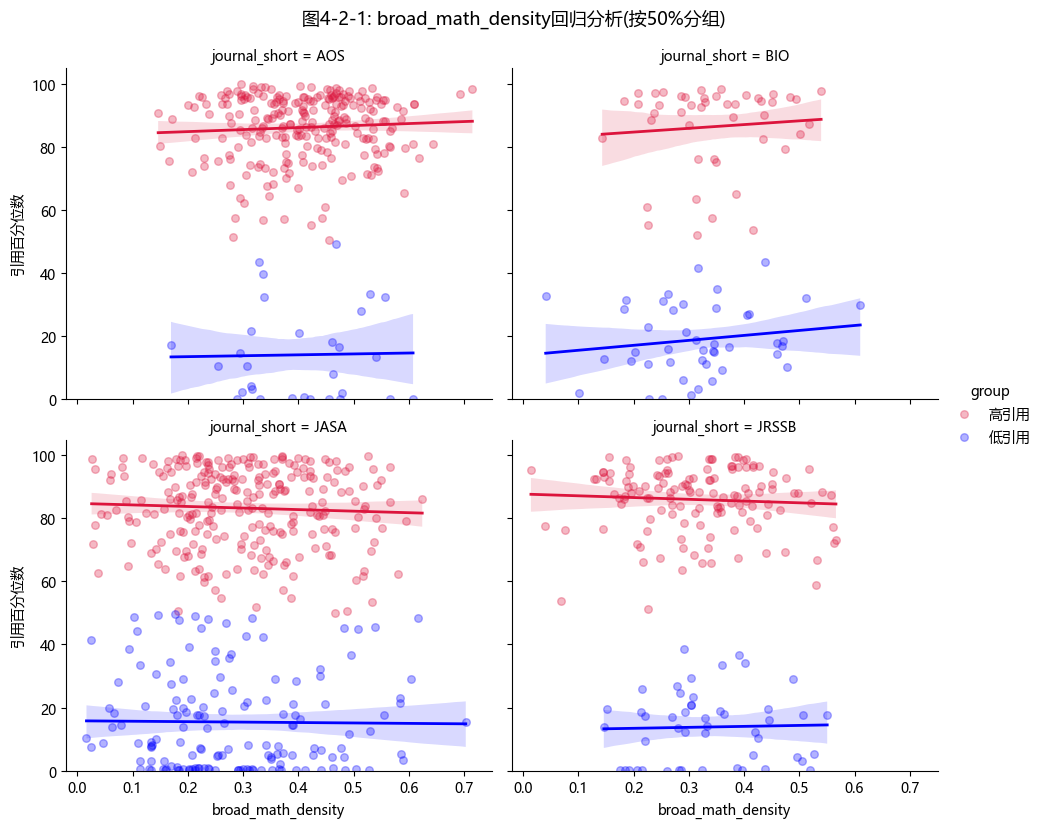

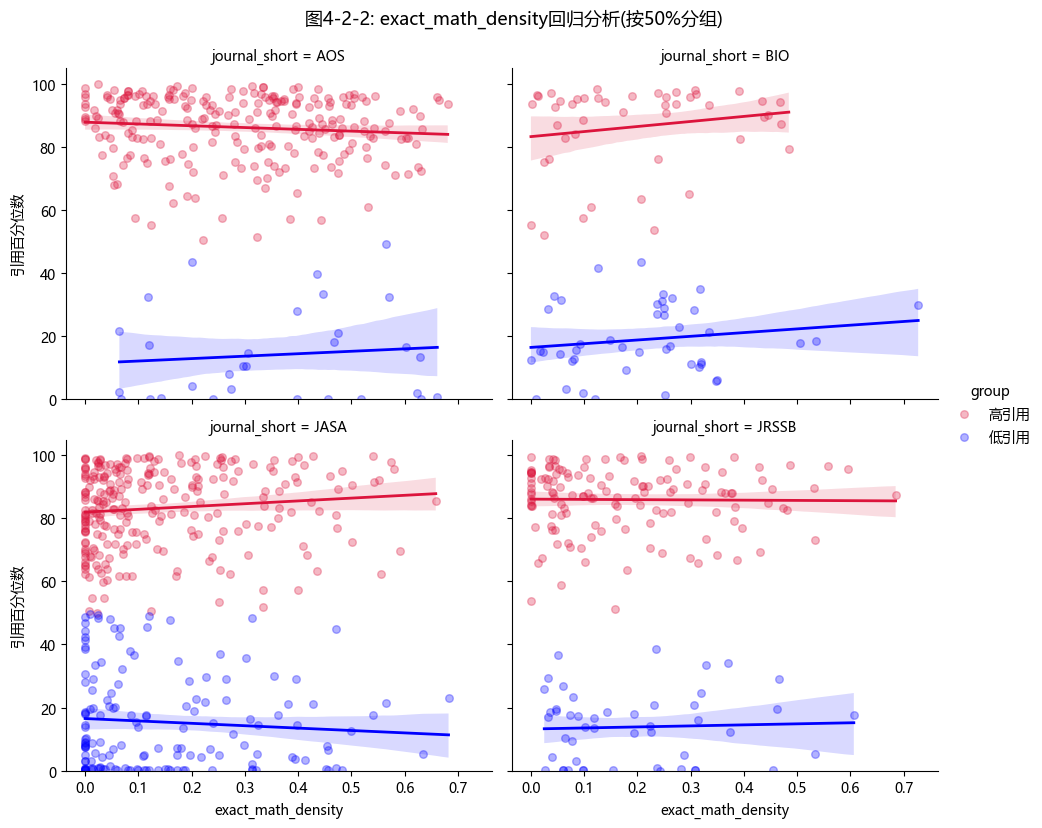

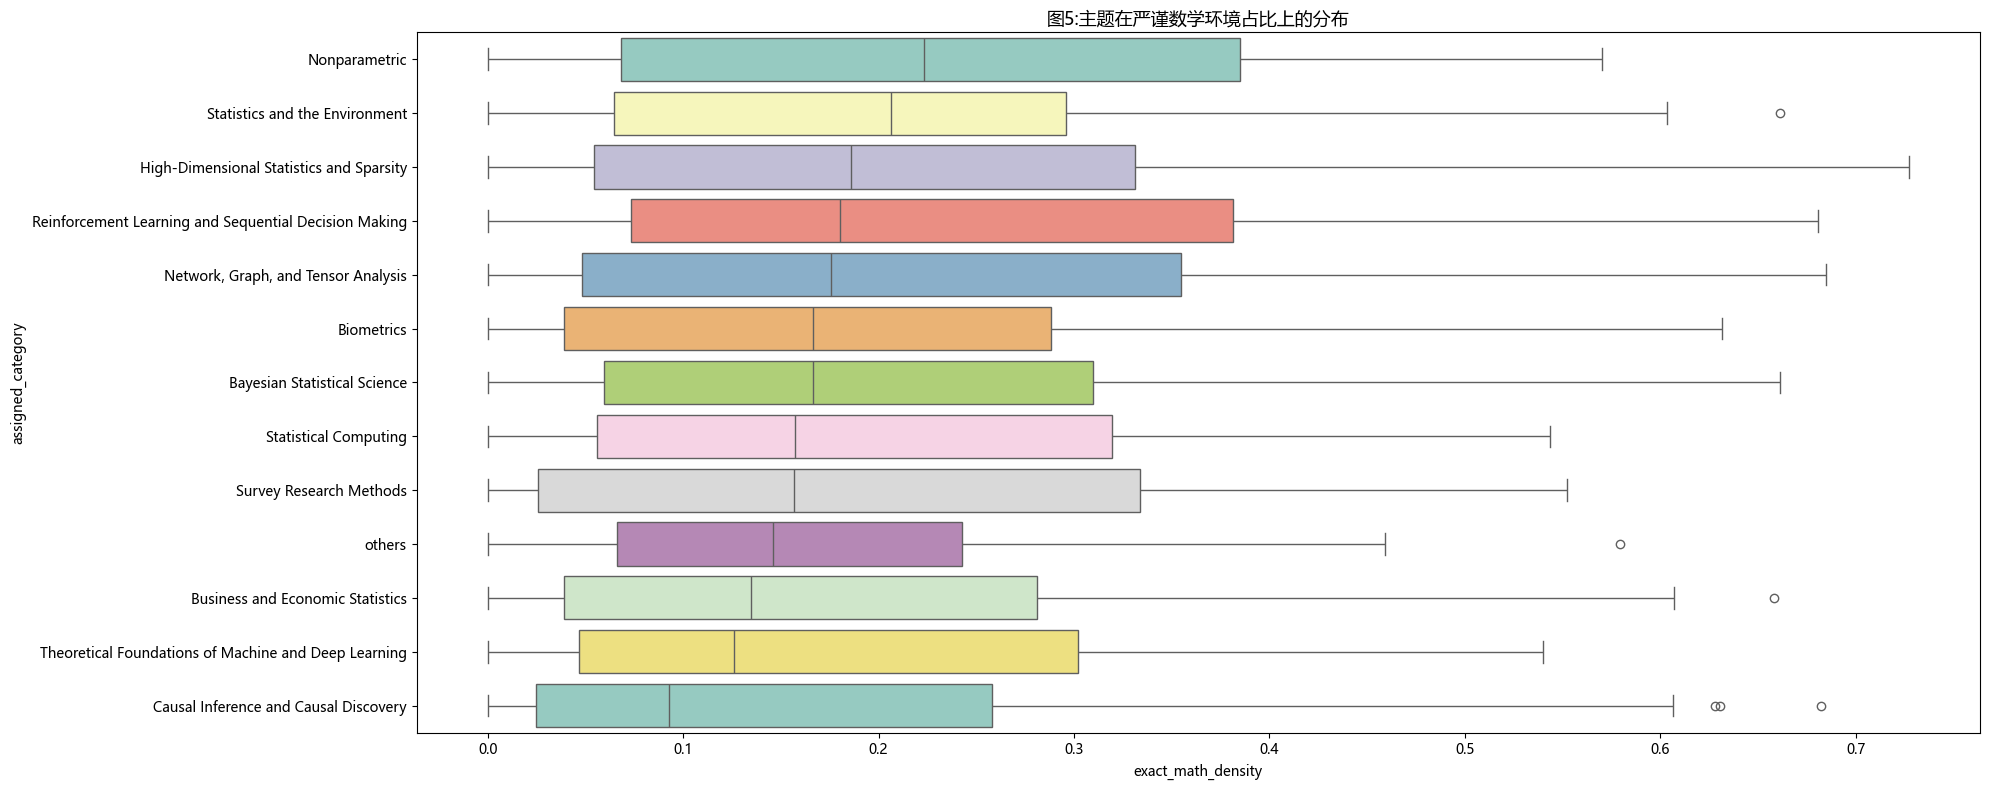

期刊间数学密度差异的p-value: 7.1232E-31
主题间数学密度差异的p-value: 4.2685E-02
主题间引用差异的p-value: 1.9424E-01
高低引用组数学密度差异的p-value: 5.7375E-05
不同数学占比等级间的引用量差异的p-value: 1.2244E-04
AOS
精准数学&引用: -0.132
宏观数学&引用: 0.046
BIO
精准数学&引用: 0.008
宏观数学&引用: 0.165
JASA
精准数学&引用: 0.009
宏观数学&引用: 0.052
JRSSB
精准数学&引用: -0.039
宏观数学&引用: -0.076
整体数据
精准数学&引用: 0.056
宏观数学&引用: 0.124
所有图表与'outcome.csv'已生成。


In [ ]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
warnings.filterwarnings('ignore')

# 预处理,合并两表
meta=pd.read_csv(r'C:\Users\lihong\.conda\stat4_2023_2026_metadata.csv')
math=pd.read_csv(r'C:\Users\lihong\.conda\all_latex_features_results.csv')
df = pd.merge(meta, math, on='paper_id', how='inner')
classif=pd.read_csv(r'C:\Users\lihong\.conda\stat4_2023_2026_metadata_classified(2).csv')
df['assigned_category']=classif['assigned_category']
# 绘图辅助函数(简化图四代码)
def draw(x, title, filename, hue=None):
    g = sns.lmplot(data=df, x=x, y='citation_percentile', col='journal_short', col_wrap=2, height=4, aspect=1.2, hue=hue,
palette={'高引用': 'crimson', '低引用': 'blue'} if hue else None,scatter_kws={'alpha': 0.3, 's': 30}, line_kws={'lw': 2})
    g.set(ylim=(0, 105), xlabel=x, ylabel='引用百分位数')
    g.figure.suptitle(title, fontsize=13, y=1.03)
    plt.savefig(f'{filename}', dpi=300, bbox_inches='tight')
    plt.show()

# 可视化
print("\n开始生成图表...")
# 图1: 各期刊抓取到的文章篇数
counts = df['journal_short'].value_counts()
counts.plot(kind='bar', rot=0, 
    title='图1: 各期刊有效论文样本数量分布')
plt.savefig(f'figure1.png', dpi=300)
plt.show()

# 图2: 引用分布
g = sns.displot(data=df, x="citation_percentile", col="journal_short",
     col_wrap=2, height=4, aspect=1.3, hue="journal_short",kind="hist", 
     bins=15, kde=True, alpha=0.3,facet_kws={'sharey': False})
g.figure.suptitle('图 2: 四大期刊引用百分位数的分布形态', fontsize=13)
plt.savefig('figure2.png', dpi=300, bbox_inches='tight')
plt.show()

# 图3:箱线图
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='journal_short', 
    y='exact_math_density', palette='Set2')
plt.title('图3: 四大期刊严谨数学环境占比对比')
plt.savefig(f'figure3.png', dpi=300)
plt.show()

# 图4系列 (共4张)
draw('broad_math_density', '图4-1-1: broad_math_density回归分析', 'figure4_11.png')
draw('exact_math_density', '图4-1-2: exact_math_density回归分析', 'figure4_12.png')
df['group'] = np.where(df['citation_percentile'] >= 50, '高引用', '低引用')
draw('broad_math_density', '图4-2-1: broad_math_density回归分析(按50%分组)', 'figure4_21.png', hue='group')
draw('exact_math_density', '图4-2-2: exact_math_density回归分析(按50%分组)', 'figure4_22.png', hue='group')

# 图 5: 主题对比
top10 = df['assigned_category'].value_counts().index
df_top = df[df['assigned_category'].isin(top10)]
fig, ax = plt.subplots(figsize=(20, 8))
col,label = 'exact_math_density','严谨数学环境占比'
order = df_top.groupby('assigned_category')[col]
order=order.median().sort_values(ascending=False).index
sns.boxplot(data=df_top, x=col, y='assigned_category', 
            order=order, ax=ax, palette='Set3')
ax.set_title(f'图5:主题在{label}上的分布', fontsize=13)
plt.tight_layout()
plt.savefig('figure5.png', dpi=300)
plt.show()

#5.统计学检验(ANOVA)
def anova(groups, name):
    valid = [g.dropna() for g in groups if len(g.dropna()) >= 5]
    stat, p = f_oneway(*valid) if len(valid) > 1 else (np.nan, np.nan)
    print(f"{name}的p-value: {p:.4E}")
    return p
df['math_level'] = pd.qcut(df['broad_math_density'], q=4, labels=['低', '中低', '中高', '高']) 
anova([df[df['journal_short'] == j]['broad_math_density'] for j in df['journal_short'].unique()], "期刊间数学密度差异")
anova([df[df['assigned_category'] == t]['broad_math_density'] for t in top10], "主题间数学密度差异")
anova([df[df['assigned_category'] == t]['citation_percentile'] for t in top10], "主题间引用差异")
anova([df[df['group'] == g]['broad_math_density'] for g in df['group'].unique()], "高低引用组数学密度差异")
anova([df[df['math_level'] == level]['citation_percentile'] for level in ['低', '中低', '中高', '高']], "不同数学占比等级间的引用量差异")


for name, g in df.groupby('journal_short'):
    # 分别计算2个相关系数
    c1 = g['exact_math_density'].corr(g['citation_percentile'])
    c2 = g['broad_math_density'].corr(g['citation_percentile'])
    
    # 打印结果，保留三位小数
    print(f"{name}")
    print(f"精准数学&引用: {c1:.3f}")
    print(f"宏观数学&引用: {c2:.3f}")

c11 = df['exact_math_density'].corr(df['citation_percentile'])
c21 = df['broad_math_density'].corr(df['citation_percentile'])
print("整体数据")
print(f"精准数学&引用: {c11:.3f}")
print(f"宏观数学&引用: {c21:.3f}")

#6.数据导出
columns = [
    'paper_id', 'title', 'journal_short', 'publication_year', 
    'institution_names', 'primary_topic', 
    'cited_by_count', 'citation_percentile', 
    'exact_math_density', 'broad_math_density']
df[columns].to_csv('outcome.csv', index=False, encoding='utf-8-sig')
print("所有图表与'outcome.csv'已生成。")